<h1 style="color:#117A65;"><b>Predicción de Churn en E-commerce</b></h1>

<p style="text-align: left; color: #555;"><b>Desarrollado por:</b> Marco Olivares Canales</p>

---

<h4 style="color:#117A65;">📌 <b>Contexto del Negocio</b></h4>

>En el sector del comercio electrónico, **retener a un cliente existente es hasta 5 veces más económico que adquirir uno nuevo**. Este proyecto desarrolla una solución analítica integral ante el desafío de la fuga silenciosa de clientes. El objetivo es identificar señales de abandono de manera temprana, permitiendo al negocio dejar de reaccionar ante la pérdida y comenzar a anticiparla.

<h4 style="color:#117A65;">🎯 <b>Objetivos de este Notebook</b></h4>

* 🔍 **Identificar** los factores críticos y patrones de comportamiento transaccional que impulsan a un cliente a dejar la plataforma. 
* 🤖 **Desarrollar** un modelo de Machine Learning capaz de predecir la probabilidad de fuga, priorizando una alta sensibilidad (maximizar el *Recall*) para no omitir clientes en riesgo.
* 📊 **Segmentar:** Clasificar a la base de clientes según su nivel de riesgo (Alto, Medio, Bajo) para optimizar el ROI de las campañas del equipo de Marketing.

<h4 style="color:#117A65;">📖 <b>Definición del Target ("Churn")</b></h4>

>Para este proyecto, el estado de abandono (*Churn*) viene **predefinido como una etiqueta binaria (`0 = Retenido`, `1 = Fugado`)** en el dataset original. Esto nos permite un enfoque de aprendizaje supervisado directo para predecir el comportamiento futuro.

---

<h4 style="color:#117A65;">📑 <b>Tabla de Contenidos</b></h4>

<span style="color:#117A65; font-size: 1.1em;"><b>1. Carga y entendimiento inicial de datos</b></span>
* Carga de Librerías
* Importación de dataset
* Inspección de estructura

<span style="color:#117A65; font-size: 1.1em;"><b>2. Limpieza y preprocesamiento base</b></span>
* Tratamiento de valores nulos y duplicados

<span style="color:#117A65; font-size: 1.1em;"><b>3. Análisis Exploratorio de Datos (EDA)</b></span>
* Distribución de la variable objetivo "churn"
* Matriz de correlación numérica lineal con churned
* Análisis bivariado y categórico

<span style="color:#117A65; font-size: 1.1em;"><b>4. Ingeniería de Características (Feature Engineering)</b></span>
* Limpieza de variables categóricas y escalado de datos numéricos

<span style="color:#117A65; font-size: 1.1em;"><b>5. Modelado Predictivo</b></span>
* División de datos (Train / Test Split)
* Entrenamiento de modelo
* Evaluación de métricas (F1-Score, Recall, Matriz de Confusión)

<span style="color:#117A65; font-size: 1.1em;"><b>6. Interpretabilidad y Segmentación</b></span>
* Importancia de variables (*Feature Importance*)

<span style="color:#117A65; font-size: 1.1em;"><b>7. Modelado predictivo (Optimización)</b></span>
* Optimización del modelo para mejorar recall
* Perfilado de segmentos de riesgo

## **1. Carga de librerías y datasets**

In [3]:
# =========================================================
# CARGA DE LIBRERÍAS
# =========================================================

# CONFIGURACIÓN DE ENTORNO Y SISTEMA
import os
import sys
import warnings
import joblib
import datetime as dt

# Desactivar alertas innecesarias
warnings.filterwarnings('ignore')

# MANIPULACIÓN DE DATOS Y MATEMÁTICAS
import pandas as pd
import numpy as np

# Configuración de visualización de tablas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# VISUALIZACIÓN GRÁFICA (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
sns.set_theme(style="whitegrid")


# MACHINE LEARNING (PREPROCESAMIENTO Y MODELADO)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Librerías cargadas.")

Librerías cargadas.


In [4]:
# =========================================================
# IMPORTACIÓN DE DATASET
# =========================================================

# Carga inicial
print("Cargando dataset...")
df = pd.read_csv("../data/raw/ecommerce_customer_churn_dataset.csv")


# Información general inicial
print(f"df_Dimensiones: {df.shape}")
print("-" * 50)
print("Información general de df:")
print("-" * 50)
df.info()
print("-" * 50)
print("Valores nulos por columna:")
print("-" * 50)
nulos = df.isnull().sum()
display(nulos[nulos > 0].sort_values(ascending=False))
print("-" * 50)
display(df.head())

Cargando dataset...
df_Dimensiones: (50000, 25)
--------------------------------------------------
Información general de df:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  fl

Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Discount_Usage_Rate              3500
Product_Reviews_Written          3500
Session_Duration_Avg             3399
Pages_Per_Session                3000
Days_Since_Last_Purchase         3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
dtype: int64

--------------------------------------------------


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


* **Análisis de estructura:** Contamos con un dataset de **50,000 registros** y **25 columnas**. Variables como identificadores personales, geografía no agrupada o columnas con valores constantes se descartarán por no aportar valor predictivo al menos durante el entrenamiento del modelo.

* **Tratamiento de nulos:** La variable con mayor cantidad de datos faltantes (`Social_Media_Engagement_Score`) tiene 6,000 nulos, mientras que el resto presenta un volumen menor (desde 5,500 en `Credit_Balance` hasta 168 en `Customer_Service_Calls`). Para no perder registros útiles, la estrategia de imputación se dividirá según la naturaleza de cada columna:

  * **Variables numéricas continuas** (ej. `Age`, `Session_Duration_Avg`, `Social_Media_Engagement_Score`): Se imputarán con la **mediana** para evitar que la distribución se sesgue por valores atípicos (outliers).
  * **Variables categóricas** (ej. `Gender`, `City`): Se imputarán con la **moda** (el valor más frecuente) para mantener la proporción de la clase mayoritaria.
  * **Variables de comportamiento o conteo** (ej. `Customer_Service_Calls`, `Returns_Rate`): Se rellenarán con **0** únicamente cuando la lógica de negocio indique que un nulo significa la ausencia de la acción (es decir, si no hay registro de llamadas, se asume que hizo 0 llamadas).

## **2. Limpieza y preprocesamiento**

In [5]:
# =========================================================
# TRATAMIENTO DE VALORES NULOS Y DUPLICADOS
# =========================================================

# Elimina columnas sin valor predictivo
cols_to_drop = ['City', 'Signup_Quarter']
df = df.drop(columns=cols_to_drop)

# Elimina duplicados
df = df.drop_duplicates()

# Separar columnas por tipo de dato
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Imputando numéricas por la mediana
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Imputando categóricas por la moda
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verificación final
print(f"Limpieza completada. Dimensiones actuales: {df.shape}")
print(f"Total de nulos restantes: {df.isnull().sum().sum()}")

Limpieza completada. Dimensiones actuales: (50000, 23)
Total de nulos restantes: 0


Con los datos limpios de nulos, sin duplicados y libres de variables ruidosas, el dataset se encuentra preparado para el análisis exploratorio.

**¿Qué buscaremos?**
* Evaluar la distribución de nuestra variable objetivo (`Churned`) para identificar si existe desbalanceo de clases.
* Descubrir patrones de comportamiento, tendencias y anomalías que diferencien a los clientes que abandonan de los que se quedan.
* Identificar las variables con mayor poder predictivo mediante el análisis de correlaciones.

**Estrategias y Herramientas Visuales:**
* **Análisis Univariado:** Histogramas y gráficos de conteo (`seaborn.histplot`, `countplot`) para entender la distribución individual de características clave.
* **Análisis Bivariado y Multivariado:** Matrices de correlación (`seaborn.heatmap`) y diagramas de caja (`boxplot`) para evaluar la relación cruzada entre las métricas de comportamiento (RFM, engagement) y la tasa de fuga.

## **3. Análisis exploratorio (EDA)**

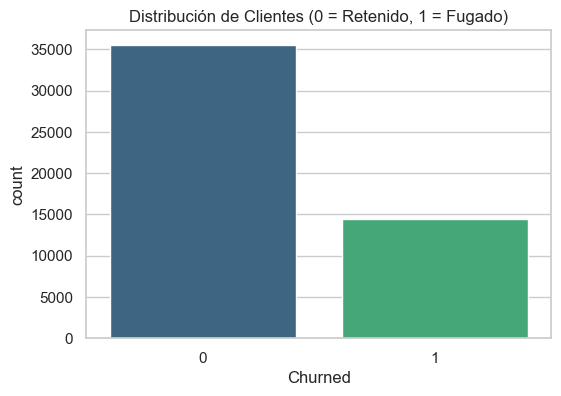

In [6]:
# =========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (CHURN)
# =========================================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churned', palette='viridis')
plt.title('Distribución de Clientes (0 = Retenido, 1 = Fugado)')
plt.show()

* **Observación principal:** Existe claramente un desbalance entre clientes fugados y retenidos, donde los retenidos tienen un mayor peso (cerca de 35,000, un 70%), mientras que los fugados representan cerca de 15,000 (un 30%).
* **Implicación tecnica:** Esto podría significar que el algoritmo tienda a predecir por defecto la clase mayoritaria. Será un desafío para el entrenamiento del modelo, obligándonos a evaluar el rendimiento con métricas como el `F1-Score o el Recall`, en lugar de la simple exactitud `Accuracy`.
* **Impacto de negocio:** Es un indicador de que la empresa está perdiendo al 30% de su base de clientes. Esta es una tasa de abandono alta para un e-commerce.

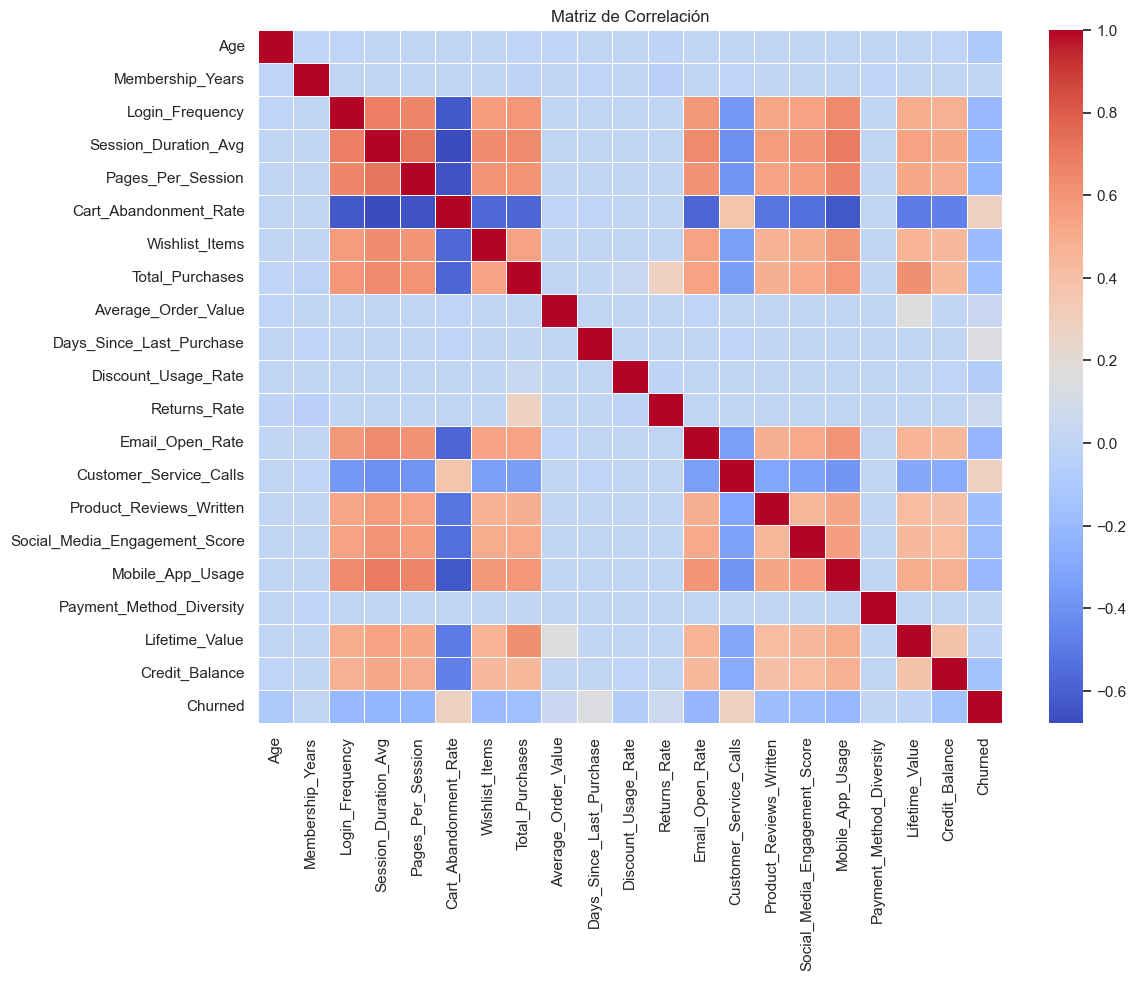

--------------------------------------------------
Top correlaciones con 'Churned':
--------------------------------------------------


Churned                          1.000000
Customer_Service_Calls           0.290384
Cart_Abandonment_Rate            0.277963
Days_Since_Last_Purchase         0.148015
Returns_Rate                     0.051122
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004767
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.074152
Age                             -0.100511
Credit_Balance                  -0.147990
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.174459
Social_Media_Engagement_Score   -0.179829
Wishlist_Items                  -0.189569
Login_Frequency                 -0.204379
Mobile_App_Usage                -0.211376
Email_Open_Rate                 -0.216233
Session_Duration_Avg            -0.219512
Pages_Per_Session               -0.224708
Name: Churned, dtype: float64

In [7]:
# =========================================================
# MATRIZ DE CORRELACIÓN NUMÉRICA
# =========================================================
plt.figure(figsize=(12, 9))
# Filtramos variables numéricas para la correlación
num_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_df.corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

# Mostrar los valores numéricos de correlación con la variable objetivo
print("-" * 50)
print("Top correlaciones con 'Churned':")
print("-" * 50)
display(corr_matrix['Churned'].sort_values(ascending=False))

* **Correlación Positiva (impulsan la fuga):**
  * **`Customer_Service_Calls` (0.29):** A mayor número de llamadas a soporte, mayor riesgo de fuga. Es un claro indicador y puede representar problemas con productos o insatisfacción general.
  * **`Cart_Abandonment_Rate` (0.28):** Abandonar el carrito frecuentemente es una señal temprana de que el cliente está perdiendo el interés o yéndose a la competencia.
  * **`Days_Since_Last_Purchase` (0.15):** A más días desde su última compra (Recency), mayor es la probabilidad de abandono.

* **Correlación Negativa (Impulsan la retención):**
  * **El Engagement:** Las variables con mayor poder para evitar la fuga son las de interacción. Visitar más páginas (`-0.22`), sesiones más largas (`-0.22`), abrir correos (`-0.22`), usar la app (`-0.21`) y loguearse con frecuencia (`-0.20`) reducen drásticamente el abandono. 
  * **Comportamiento transaccional:** Tener saldo a favor (`Credit_Balance`: `-0.15`) y un mayor volumen histórico de compras (`Total_Purchases`: `-0.16`) también retienen al usuario.

* **Variables sin impacto aparente:**
  * Curiosamente, `Membership_Years` (0.00) y `Lifetime_Value` (-0.01) casi no tienen correlación lineal con la fuga. Esto indica que ser un cliente antiguo no garantiza lealtad futura si sus niveles actuales de interacción (engagement) decaen.

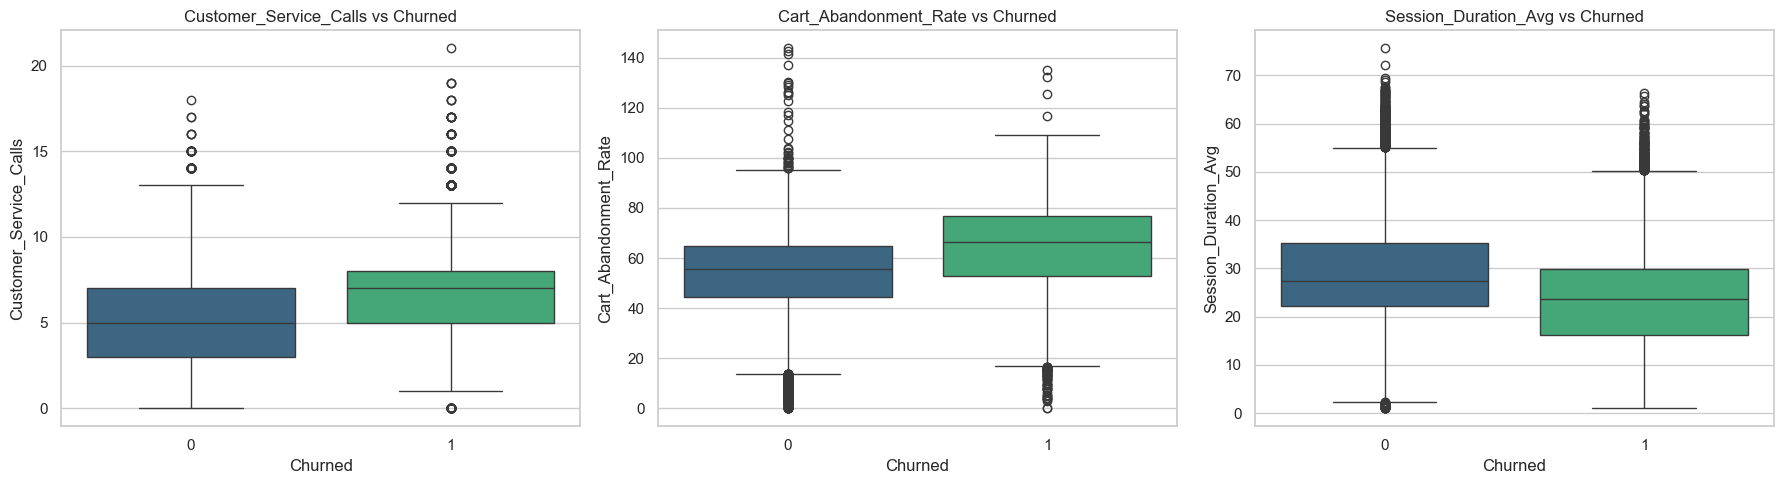

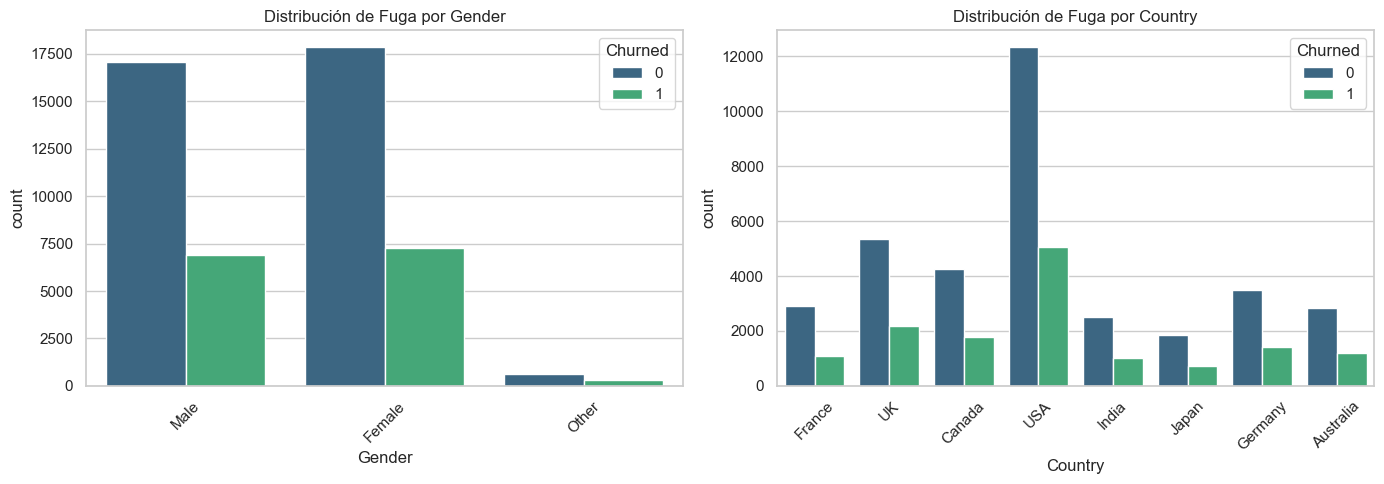

In [8]:
# =========================================================
# ANÁLISIS BIVARIADO Y CATEGÓRICO
# =========================================================

# Boxplots de las variables numéricas Top vs Churn (Impacto directo y Outliers)
top_vars = ['Customer_Service_Calls', 'Cart_Abandonment_Rate', 'Session_Duration_Avg']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(top_vars):
    sns.boxplot(data=df, x='Churned', y=var, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{var} vs Churned')

plt.tight_layout()
plt.show()

# Análisis de Variables Categóricas vs Churn
# Filtrar categóricas reales
cat_vars = ['Gender', 'Country'] 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, var in enumerate(cat_vars):
    sns.countplot(data=df, x=var, hue='Churned', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de Fuga por {var}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**1. Variables Numéricas vs. Fuga (Boxplots):**
* **`Customer_Service_Calls`:** La mediana de los clientes fugados es visiblemente mayor. El riesgo de abandono se dispara a partir de las 5 llamadas. El valor atípico (outlier) en 0 para la clase "Churned" es muy revelador: indica que existe un grupo de clientes que abandonan el servicio en silencio, sin siquiera intentar contactar a soporte.
* **`Cart_Abandonment_Rate`:** Aunque hay superposición entre ambos grupos, la caja de los fugados está desplazada hacia arriba. Esto confirma que una mayor tasa de abandono de carrito aumenta el riesgo de fuga. Los outliers inferiores indican que hay clientes que nunca abandonan carritos, pero aun así deciden irse.
* **`Session_Duration_Avg`:** Se confirma visualmente la correlación negativa. Las sesiones de los clientes retenidos son significativamente más largas. Esto ratifica que el *engagement* (tiempo invertido en la plataforma) es un escudo protector contra el abandono.

**2. Variables Categóricas vs. Fuga:**
* **`Gender`:** La proporción de fuga es prácticamente idéntica entre hombres y mujeres. La baja cantidad en la categoría "Other" responde simplemente a la distribución poblacional de la muestra. **Conclusión:** El género no tiene poder predictivo para este modelo.
* **`Country`:** Aunque USA tiene el mayor volumen absoluto de clientes (y por ende, más clientes retenidos), la *proporción* de fuga frente a retención se mantiene constante en todos los países. **Conclusión:** La geografía nos indica el tamaño del mercado, pero no discrimina el comportamiento de fuga. 

**El comportamiento transaccional y de interacción (Engagement/Soporte) es el verdadero predictor del Churn, mientras que los datos demográficos básicos (País, Género) son prácticamente ruido estadístico para este problema.**

## **4. Ingeniería de Características (Feature Engineering)**

In [9]:
# =========================================================
# ELIMINAR VARIABLES CATEGÓRICAS Y ESCALADO
# =========================================================

# Eliminando variables sin poder predictivo
df = df.drop(columns=['Gender', 'Country'])

# Separar las características (X) de la variable objetivo (y)
X = df.drop(columns=['Churned'])
y = df['Churned']

# Escalar las variables numéricas
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Feature Engineering completado.")
print(f"Dimensiones de las características (X): {X_scaled.shape}")
print("-" * 50)
display(X_scaled.head())

Feature Engineering completado.
Dimensiones de las características (X): (50000, 20)
--------------------------------------------------


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance
0,0.449670,-0.040799,0.304118,-0.019266,-0.741695,-0.397970,-0.416436,-0.585925,-0.161746,0.164025,0.219642,-0.777562,-0.214209,1.242772,0.534652,-0.665654,0.168429,-1.231912,-0.537119,0.276395
1,-0.157149,-0.672148,0.432150,1.438275,0.431898,-1.190229,-1.069915,0.910390,-0.231633,1.445821,0.780348,0.448591,1.578436,0.494218,0.091480,-0.080417,0.448109,0.612019,-0.411309,0.925225
2,0.623047,-0.040799,-0.208008,-0.266953,-1.942582,0.848763,-1.069915,-0.571674,0.241517,-0.632767,-1.437253,0.840279,-1.502898,-0.628613,-0.794865,-0.080417,-1.174035,-0.309946,-0.166302,0.310134
3,1.576619,-0.186495,-0.208008,1.028639,1.660078,-0.944567,1.544001,0.269112,0.137911,0.614385,0.108083,-0.198545,1.477645,-1.377168,0.977824,2.938988,1.309524,0.612019,0.992343,0.618977
4,-0.243837,0.056331,2.224591,2.267073,-0.086666,-2.332555,1.544001,2.762969,0.103565,1.515107,-0.808642,-0.181515,1.225666,-1.751445,3.636856,2.788795,3.479841,1.533984,1.764322,2.937463


* **Eliminación de ruido:** Se descartaron las variables categóricas (`Gender` y `Country`) al confirmar en el EDA que mantenían la misma proporción de fuga y no aportaban valor predictivo.

* **Separación de datos:** Se dividió el dataset aislando la variable objetivo (`Churned`) de las características predictoras (X).

* **Escalado (Estandarización):** Se normalizaron las 20 variables numéricas restantes usando `StandardScaler`. Esto garantiza que todas las métricas estén en la misma escala y evita que los algoritmos se sesguen por variables con valores absolutos altos (como `Lifetime_Value`) frente a valores pequeños.

## **5. Modelado Predictivo v1**

Set de entrenamiento: (40000, 20)
Set de prueba: (10000, 20)
--------------------------------------------------
Reporte de Clasificación:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7110
           1       0.92      0.77      0.84      2890

    accuracy                           0.91     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.91      0.91      0.91     10000



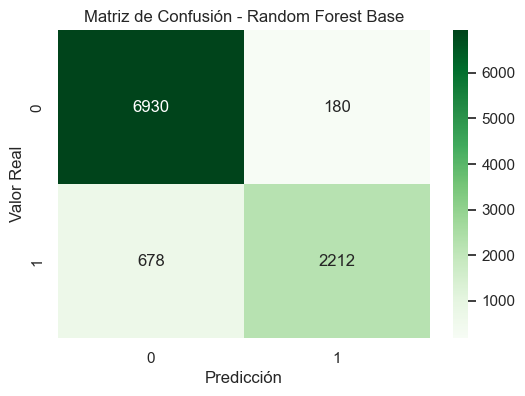

In [10]:
# =========================================================
# MODELADO PREDICTIVO
# =========================================================

# División de datos (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")
print("-" * 50)

# Entrenamiento del Modelo Base
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred = rf_model.predict(X_test)

# Evaluación
print("Reporte de Clasificación:")
print("-" * 50)
print(classification_report(y_test, y_pred))

# Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest Base')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

**1. Matriz de Confusión**
* **Cuadrante Superior Izquierdo (6930) - Verdaderos Negativos:** Clientes retenidos (0) que el modelo identificó correctamente. El algoritmo es excelente reconociendo a los usuarios leales.
* **Cuadrante Superior Derecho (180) - Falsos Positivos:** Clientes retenidos (0) que el modelo confundió con posibles fugas (1). Es un margen de error muy bajo y "barato" para el negocio.
* **Cuadrante Inferior Derecho (2212) - Verdaderos Positivos:** Clientes que se fugaron (1) y el modelo logró detectar a tiempo. **Esta es la métrica de éxito de nuestro algoritmo.**
* **Cuadrante Inferior Izquierdo (678) - Falsos Negativos:** Clientes que se fugaron (1), pero el modelo pensó que estaban a salvo (0). Este es el "punto ciego" del algoritmo y donde está la pérdida económica real.

**2. Reporte de Clasificación**
* **Precisión (0.92):** Cuando el modelo enciende la alarma de fuga, acierta el 92% de las veces.
* **Recall / Sensibilidad (0.77):** Significa que el modelo logra detectar al 77% de todos los clientes que realmente se van a fugar. Ese 23% faltante son los que se nos escapan en silencio.
* **F1-Score (0.84):** Una calificación general de 84/100 para la detección de fugas, lo cual es un excelente punto de partida para un modelo base.
* **Accuracy (0.91):** El modelo acierta el 91% del total de los casos. Aunque es alto, debido al desbalanceo inicial no nos podemos fiar solo de este valor ya que es facil tener un accyracy alto midiendo solo la clase mayoritaria.

## **6. Interpretabilidad**

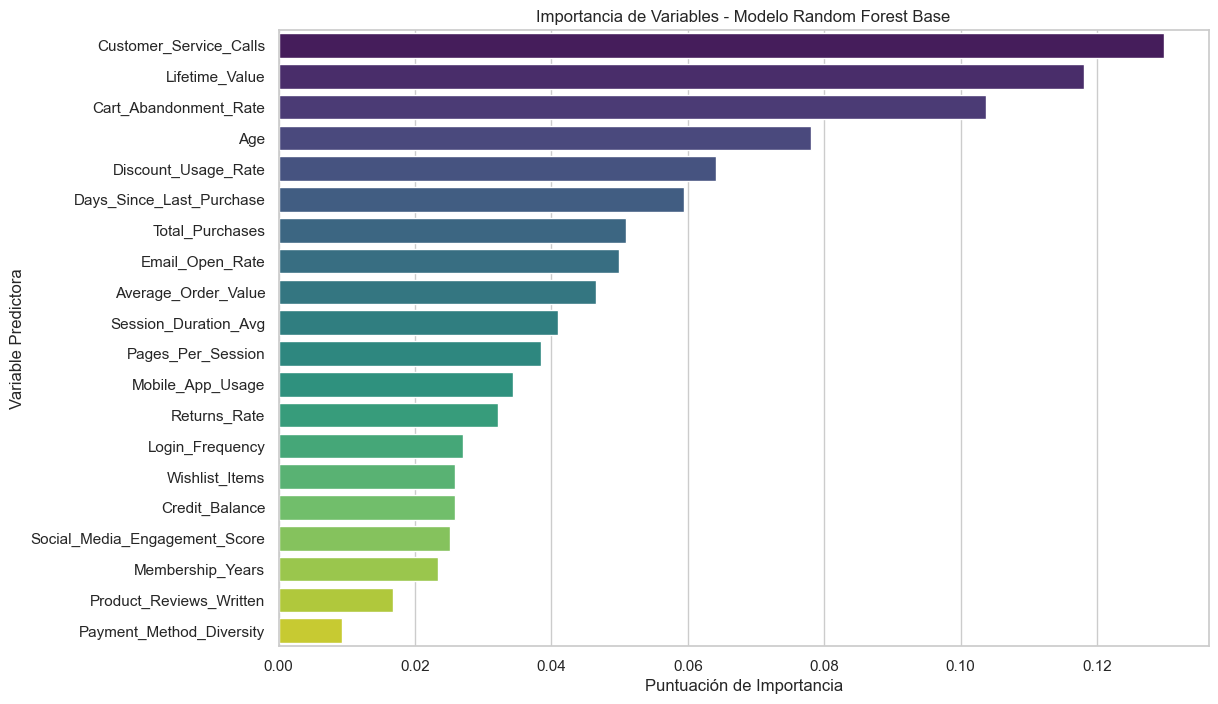

Top 5 Variables más influyentes en la predicción:
--------------------------------------------------


,Feature,Importance
13,Customer_Service_Calls,0.129872
18,Lifetime_Value,0.118107
5,Cart_Abandonment_Rate,0.103651
0,Age,0.078028
10,Discount_Usage_Rate,0.064144


In [11]:
# =========================================================
# IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE)
# =========================================================

# Obtener las importancias del modelo entrenado
importances = rf_model.feature_importances_
feature_names = X_scaled.columns

# Creando un df para visualizar fácilmente
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Importancia de Variables - Modelo Random Forest Base')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variable Predictora')
plt.show()

# Mostrar las Top 5 variables
print("Top 5 Variables más influyentes en la predicción:")
print("-" * 50)
display(feature_imp_df.head(5))

El modelo Random Forest nos revela cuáles son los factores más decisivos para predecir la fuga de un cliente, detectando patrones complejos que el análisis lineal no pudo ver por sí solo:

* **`Customer_Service_Calls` (13.0%):** Se confirma como el principal indicador de alerta roja. La insatisfacción que lleva al usuario a contactar repetidamente a soporte es el predictor número uno del abandono.

* **`Lifetime_Value` (11.8%) y `Age` (7.8%):** Aunque en el EDA mostraron nula correlación lineal aislada, el modelo descubrió que el valor histórico del cliente y su edad interactúan fuertemente con otros factores para determinar su lealtad.

* **`Cart_Abandonment_Rate` (10.3%):** La indecisión o frustración en el carrito no solo es una venta perdida hoy, sino un paso previo al abandono definitivo de la plataforma.

* **`Discount_Usage_Rate` (6.4%):** La sensibilidad al precio y la dependencia de las promociones juegan un rol clave; clientes que solo compran con descuento pueden ser más propensos a irse si la competencia ofrece algo más barato.

## **7. Modelado Predictivo v2 (optimización)**

In [12]:
# =========================================================
# OPTIMIZACIÓN DEL MODELO (Mejora de Recall)
# =========================================================


# Definir combinaciones a probar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

# Configurar búsqueda priorizando Recall
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall', 
    cv=3,
    n_jobs=-1
)

print("Entrenando combinaciones...")
print("-" * 50)
grid_search.fit(X_train, y_train)

# Evaluar el mejor modelo
best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test)

print(f"Mejores parámetros: {grid_search.best_params_}")
print("-" * 50)
print("Reporte del Modelo Optimizado:")
print("-" * 50)
print(classification_report(y_test, y_pred_opt))

Entrenando combinaciones...
--------------------------------------------------
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
--------------------------------------------------
Reporte del Modelo Optimizado:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7110
           1       0.84      0.83      0.83      2890

    accuracy                           0.90     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.90      0.90      0.90     10000



Al priorizar el Recall, obtuvimos el comportamiento exacto que buscábamos para el negocio:

* **Recall subió (0.77 a 0.83):** Ahora el modelo captura al 83% de los clientes reales que se van a fugar.

* **Precisión bajó (0.92 a 0.84):** A cambio de detectar más fugas, el modelo se volvió un poco más "paranoico" y generará algunas falsas alarmas más. Comercialmente, esto es preferible: es más barato dar un descuento de retención a un cliente leal por error, que perder por completo a un cliente que se iba a fugar.

* **Control de Sobreajuste:** Limitar la profundidad (`max_depth=10`) impidió que el algoritmo memorizara el ruido de los datos, haciéndolo más robusto para producción.

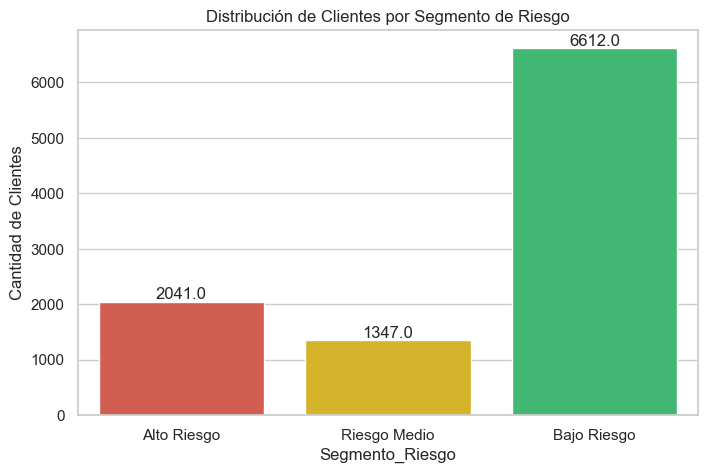

In [13]:
# =========================================================
# PERFILADO Y SEGMENTACIÓN DE RIESGO
# =========================================================

#  Probabilidades de fuga (clase 1) para el set de prueba
probabilidades_fuga = best_rf.predict_proba(X_test)[:, 1]

# Crea df con los resultados
resultados = pd.DataFrame({
    'Probabilidad_Fuga': probabilidades_fuga,
    'Fuga_Real': y_test.values
})

# Definiendo reglas de segmentación
def segmentar_riesgo(prob):
    if prob >= 0.70:
        return 'Alto Riesgo'
    elif prob >= 0.40:
        return 'Riesgo Medio'
    else:
        return 'Bajo Riesgo'

resultados['Segmento_Riesgo'] = resultados['Probabilidad_Fuga'].apply(segmentar_riesgo)

# Visualización de distribución de segmentos
plt.figure(figsize=(8, 5))
colores_riesgo = ['#e74c3c', '#f1c40f', '#2ecc71'] # Rojo, Amarillo, Verde

ax = sns.countplot(
    data=resultados, 
    x='Segmento_Riesgo', 
    order=['Alto Riesgo', 'Riesgo Medio', 'Bajo Riesgo'], 
    palette=colores_riesgo
)

plt.title('Distribución de Clientes por Segmento de Riesgo')
plt.ylabel('Cantidad de Clientes')

# Añadir etiquetas
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()

* <span style="color:#e74c3c;"><b>Alto Riesgo (2041 clientes - Probabilidad > 70%):</b></span> Zona crítica. Estos clientes tienen casi un pie fuera de la plataforma. <br>
<b>Acción recomendada:</b> Campaña de retención agresiva e inmediata.

* <span style="color:#f39c12;"><b>Riesgo Medio (1347 clientes - Probabilidad 40% - 70%):</b></span> Zona de precaución. Están mostrando señales tempranas de enfriamiento. <br>
<b>Acción recomendada:</b> Campañas automatizadas suaves.

* <span style="color:#2ecc71;"><b>Bajo Riesgo (6612 clientes - Probabilidad < 40%):</b></span> Clientes leales y con buen <i>engagement</i>. <br>
<b>Acción recomendada:</b> No intervenir con presupuesto de retención.
<br>

**Al enfocar los esfuerzos económicos de retención solo en los 2041 clientes de alto riesgo, la empresa optimiza drásticamente su presupuesto.**

In [16]:
# =========================================================
# EXPORTACIONES
# =========================================================

# Exportar el modelo optimizado
joblib.dump(best_rf, '../models/modelo_churn_rf.pkl')

# Exportar el escalador
joblib.dump(scaler, '../models/scaler_churn.pkl')

print("Archivos exportados correctamente")

Archivos exportados correctamente


In [20]:
# =========================================================
# EXPORTACIÓN PARA BI
# =========================================================

# Recuperar los datos sin escalar del set de prueba
df_bi = X.loc[X_test.index].copy()

# Añadiendo el valor de Churn
df_bi['Churn_Real'] = y_test.values

# Añade las probabilidades y el segmento de riesgo calculados
df_bi['Probabilidad_Fuga'] = probabilidades_fuga
df_bi['Segmento_Riesgo'] = resultados['Segmento_Riesgo'].values

# Exportar el csv
df_bi.to_csv('../data/processed/dataset_bi.csv', index=False)

print("Dataset para BI exportado correctamente.")

Dataset para BI exportado correctamente.


<h1 style="color:#117A65;"><b>Conclusión y Siguientes Pasos</b></h1>

Tras ejecutar el ciclo completo de la Fase de Modelado, los datos han sido transformados en una herramienta estratégica accionable.

<h3 style="color:#117A65;"><b>📊 Resumen de Hallazgos</b></h3>

* 👤 **Perfil del Cliente Fugado:** La fuga no está determinada por el país o el género, sino por la fricción en el servicio (`Customer_Service_Calls`) y la pérdida de interés en el proceso de compra (`Cart_Abandonment_Rate`).
* 🛡️ **Poder del Engagement:** El tiempo de sesión y la frecuencia de login actúan como "escudos" naturales. Fomentar el uso de la app y la apertura de correos reduce la probabilidad de abandono en un 22%.
* 🤖 **Rendimiento del Modelo:** El modelo final (Random Forest Optimizado) alcanza un **Recall del 83%**, lo que significa que detectamos a 8 de cada 10 clientes antes de que se vayan.

<h3 style="color:#117A65;"><b>💡 Recomendación Final de Negocio</b></h3>

> Priorizar la atención de los **2,041 clientes identificados con Riesgo Alto**. Una reducción del 10% en la fuga de este grupo específico representaría un incremento directo en el *Retention Rate* global y un ahorro significativo en costos de adquisición de nuevos clientes (CAC).

---

<h3 style="color:#117A65;"><b>🚀 Continuidad del Proyecto</b></h3>

El entorno predictivo está consolidado y listo para consumo. Se han exportado exitosamente:
* El modelo entrenado (`modelo_churn_rf.pkl`)
* El escalador de datos (`scaler_churn.pkl`)
* El dataset final con las probabilidades de riesgo asignadas

**Siguientes pasos:** El output de este notebook pasa a la **Fase Data Viz** Estos datos alimentarán el dashboard interactivo que permitirá al equipo de Marketing monitorear los segmentos de riesgo y ejecutar sus campañas.

<br>

<p style="text-align: right; font-style: italic; color: #555;">Marco Olivares Canales</p>